In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random

# Define a list of colors you like
colors = [# Blues & Teals
    'skyblue', 'cornflowerblue', 'steelblue', 'royalblue', 'dodgerblue',
    'deepskyblue', 'teal', 'darkcyan', 'cadetblue', 'turquoise',
    
    # Reds & Oranges
    'salmon', 'tomato', 'coral', 'lightcoral', 'indianred', 
    'firebrick', 'darkorange', 'orange', 'gold', 'crimson',
    
    # Greens
    'lightgreen', 'limegreen', 'forestgreen', 'mediumseagreen', 
    'seagreen', 'olive', 'yellowgreen', 'mediumspringgreen',
    
    # Purples & Pinks
    'orchid', 'mediumorchid', 'plum', 'violet', 'mediumpurple', 
    'blueviolet', 'darkmagenta', 'hotpink', 'deeppink', 'palevioletred',
    
    # Earth Tones / Greys
    'sienna', 'peru', 'chocolate', 'sandybrown', 'slategrey'
    ]

# Pick one randomly
random_color = random.choice(colors)

df = pd.read_csv("data/e12a7ddcea5f5b05cf5f23fdfc7cb4c8494b26cd.csv")
df.head()

,name,version,downloads,created_at,direct_deps,all_deps,a:vulnerability,a:notice,a:unmaintained,a:unsound,a:yanked,a:advisory-ignored,a:yanked-ignored,a:index-failure,a:index-cache-load-failure,a:advisory-not-detected,a:yanked-not-detected,a:unknown-advisory
0,b,0.2.0,3139,2020-02-11T01:31:37.680168Z,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,i,0.1.0,1091,2024-12-02T20:36:14.609300Z,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,ah,0.0.0,2106,2021-01-01T05:17:51.161059Z,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,b3,0.1.9,1815,2023-10-26T17:13:29.445821Z,10,35,0,0,1,0,0,0,0,0,0,0,0,0
4,gh,0.1.0,2337,2019-02-13T12:06:03.700438Z,1,15,0,0,0,0,0,0,0,0,0,0,0,0


In [2]:
df.describe()

,downloads,direct_deps,all_deps,a:vulnerability,a:notice,a:unmaintained,a:unsound,a:yanked,a:advisory-ignored,a:yanked-ignored,a:index-failure,a:index-cache-load-failure,a:advisory-not-detected,a:yanked-not-detected,a:unknown-advisory
count,2.003060e+05,200306.000000,200306.000000,200306.000000,200306.000000,200306.000000,200306.000000,200306.000000,200306.0,200306.0,200306.000000,200306.0,200306.0,200306.0,200306.0
mean,2.211651e+05,6.027124,68.368646,0.938020,0.000115,0.957884,0.425155,0.249528,0.0,0.0,0.010594,0.0,0.0,0.0,0.0
std,4.441948e+06,7.664270,101.547770,2.975774,0.010715,1.990972,1.270669,1.005067,0.0,0.0,1.910469,0.0,0.0,0.0,0.0
min,6.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
25%,7.270000e+02,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
50%,1.580000e+03,4.000000,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
75%,2.223000e+03,8.000000,97.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
max,3.998992e+08,377.000000,1467.000000,58.000000,1.000000,34.000000,29.000000,75.000000,0.0,0.0,537.000000,0.0,0.0,0.0,0.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200306 entries, 0 to 200305
Data columns (total 18 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   name                        200304 non-null  object
 1   version                     200306 non-null  object
 2   downloads                   200306 non-null  int64 
 3   created_at                  200306 non-null  object
 4   direct_deps                 200306 non-null  int64 
 5   all_deps                    200306 non-null  int64 
 6   a:vulnerability             200306 non-null  int64 
 7   a:notice                    200306 non-null  int64 
 8   a:unmaintained              200306 non-null  int64 
 9   a:unsound                   200306 non-null  int64 
 10  a:yanked                    200306 non-null  int64 
 11  a:advisory-ignored          200306 non-null  int64 
 12  a:yanked-ignored            200306 non-null  int64 
 13  a:index-failure             2

In [4]:
df["a:notice"].value_counts()

a:notice
0    200283
1        23
Name: count, dtype: int64

In [5]:
to_drop = [
    "a:advisory-ignored",
    "a:yanked-ignored",
    "a:index-cache-load-failure",
    "a:advisory-not-detected",
    "a:yanked-not-detected",
    "a:unknown-advisory",
    "a:index-failure",
]

In [6]:
df.drop(
    columns=to_drop,
    inplace=True,
)
df.head()

,name,version,downloads,created_at,direct_deps,all_deps,a:vulnerability,a:notice,a:unmaintained,a:unsound,a:yanked
0,b,0.2.0,3139,2020-02-11T01:31:37.680168Z,0,0,0,0,0,0,0
1,i,0.1.0,1091,2024-12-02T20:36:14.609300Z,0,0,0,0,0,0,0
2,ah,0.0.0,2106,2021-01-01T05:17:51.161059Z,0,0,0,0,0,0,0
3,b3,0.1.9,1815,2023-10-26T17:13:29.445821Z,10,35,0,0,1,0,0
4,gh,0.1.0,2337,2019-02-13T12:06:03.700438Z,1,15,0,0,0,0,0


In [7]:
df["time"] = pd.to_datetime(df["created_at"], format="mixed", utc=True)

In [8]:
df["time"].head()

0   2020-02-11 01:31:37.680168+00:00
1   2024-12-02 20:36:14.609300+00:00
2   2021-01-01 05:17:51.161059+00:00
3   2023-10-26 17:13:29.445821+00:00
4   2019-02-13 12:06:03.700438+00:00
Name: time, dtype: datetime64[ns, UTC]

In [9]:
df["downloads"].describe()

count    2.003060e+05
mean     2.211651e+05
std      4.441948e+06
min      6.000000e+00
25%      7.270000e+02
50%      1.580000e+03
75%      2.223000e+03
max      3.998992e+08
Name: downloads, dtype: float64

In original download-distribution the distance between min-and max is big, so log-distribution is used instead.

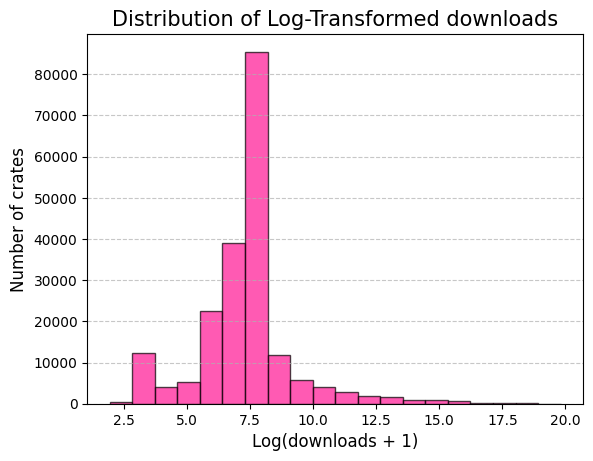

In [10]:
df["log-downloads"] = np.log1p(df["downloads"])
df["log-downloads"].hist(bins=20, edgecolor='black', alpha=0.7, color=random_color)
plt.title("Distribution of Log-Transformed downloads", fontsize=15)
plt.xlabel("Log(downloads + 1)", fontsize=12)
plt.ylabel("Number of crates", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.grid(axis='x', visible=False)
plt.show()

As shown by the log-transformed download distribution, there is a pronounced spike at the lower end corresponding to packages with very few downloads. These packages are often experimental, inactive, or used by a negligible number of users. Since the goal of this analysis is to study vulnerabilities in packages that have a meaningful impact on the ecosystem, we restrict our focus to relatively more widely used packages and exclude this extreme low-download tail.

In [11]:
df["downloads"].describe(percentiles=[0.001, 0.01, 0.05, 0.07, 0.1])

count    2.003060e+05
mean     2.211651e+05
std      4.441948e+06
min      6.000000e+00
0.1%     1.400000e+01
1%       2.000000e+01
5%       3.000000e+01
7%       5.000000e+01
10%      1.880000e+02
50%      1.580000e+03
max      3.998992e+08
Name: downloads, dtype: float64

As it can bee seen, bottom 7% of pacages do not exceed 50 downloads. So we are triming that end.

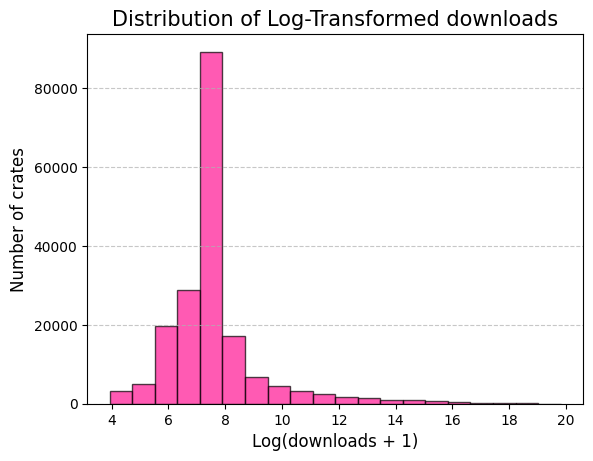

In [12]:
q = df["downloads"].quantile(0.07)
df_trimmed = df[df["downloads"] >= q].copy()
df_trimmed["log_downloads"] = np.log1p(df_trimmed["downloads"])

df_trimmed["log-downloads"].hist(bins=20, edgecolor='black', alpha=0.7, color=random_color)
plt.title("Distribution of Log-Transformed downloads", fontsize=15)
plt.xlabel("Log(downloads + 1)", fontsize=12)
plt.ylabel("Number of crates", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.grid(axis='x', visible=False)
plt.show()

In [13]:
len(df_trimmed)

186287

In [14]:
len(df) - len(df_trimmed)

14019

Now let's devide packages into groups based on number of downloads.

In [15]:
bins = [
    0,
    1_000,
    2_000,
    5_000,
    10_000,
    100_000,
    1_000_000,
    np.inf,
]
labels = [
    "0–1k",
    "1k–2k",
    "2k–5k",
    "5k–10k",
    "10k–100k",
    "100k–1M",
    ">1M",
]
df_trimmed["download_group"] = pd.cut(
    df_trimmed["downloads"], bins=bins, labels=labels, include_lowest=True
)

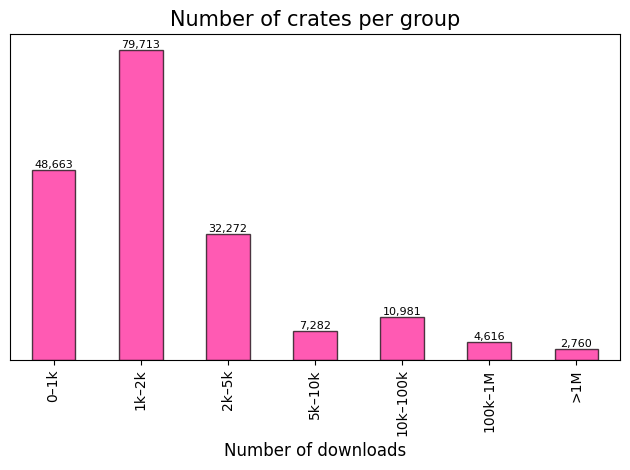

In [16]:
df_trimmed_groupped = df_trimmed.groupby("download_group", observed=False)["downloads"].agg(n="count")
ax = df_trimmed_groupped.plot(kind="bar", edgecolor='black', alpha=0.7, color=random_color, legend=None)
# Annotate each bar
for i, n in enumerate(df_trimmed_groupped["n"]):
    ax.text(i, n, f"{n:,}", ha="center", va='bottom', fontsize=8)
ax.get_yaxis().set_visible(False)
plt.xlabel("Number of downloads", fontsize=12)
plt.title("Number of crates per group", fontsize=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.grid(axis='x', visible=False)
plt.tight_layout()
plt.show()

In [17]:
df_trimmed["Failed_count"] = (
    df_trimmed["a:vulnerability"]
    + df_trimmed["a:unsound"]
    # + df_trimmed["a:notice"]
    # + df_trimmed["a:yanked"]
    # + df_trimmed["a:unmaintained"]
)
# failed at least once
df_trimmed["Failed_bool"] = df_trimmed["Failed_count"] > 0

In [18]:
df_trimmed["Failed_bool"].value_counts()

Failed_bool
False    131409
True      54878
Name: count, dtype: int64

In [19]:
df_trimmed["Failed_count"].value_counts()

Failed_count
0     131409
1      19957
2       9417
3       5460
4       3922
       ...  
54         1
67         1
58         1
68         1
56         1
Name: count, Length: 67, dtype: int64

In [20]:
print(
    f"{round(sum(df_trimmed['Failed_bool'] == 0) / len(df_trimmed) * 100, 3)}% investigated packages haven't got any vulnerability reported "
)
print(
    f"{round(sum(df_trimmed['Failed_bool'] == 1) / len(df_trimmed) * 100, 3)}% investigated packages have got at least one vulnerability reported "
)

70.541% investigated packages haven't got any vulnerability reported 
29.459% investigated packages have got at least one vulnerability reported 


In [21]:
df_trimmed.downloads.describe()

count    1.862870e+05
mean     2.378068e+05
std      4.605627e+06
min      5.000000e+01
25%      9.560000e+02
50%      1.619000e+03
75%      2.363000e+03
max      3.998992e+08
Name: downloads, dtype: float64

Now let's devide package failure rates (the percantage of failed crates in the group) into groups as it was done before.

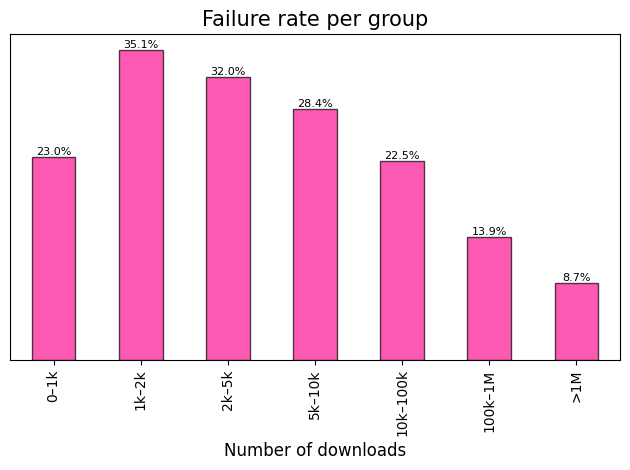

In [22]:
stats = df_trimmed.groupby("download_group", observed=False)["Failed_bool"].agg(
    vuln_rate="mean", n="count"
)

stats["vuln_rate"] *= 100
ax = stats["vuln_rate"].plot(kind="bar", edgecolor='black', alpha=0.7, color=random_color)

# Annotate each bar
for i, rate in enumerate(stats["vuln_rate"]):
    ax.text(i, rate, f"{rate:.1f}%", ha="center", va='bottom', fontsize=8)

ax.get_yaxis().set_visible(False)
plt.xlabel("Number of downloads", fontsize=12)
plt.title("Failure rate per group", fontsize=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.grid(axis='x', visible=False) # Hiding x-grid often looks cleaner for histograms
plt.tight_layout()
plt.show()

Investigate avarage number of failures count for each group

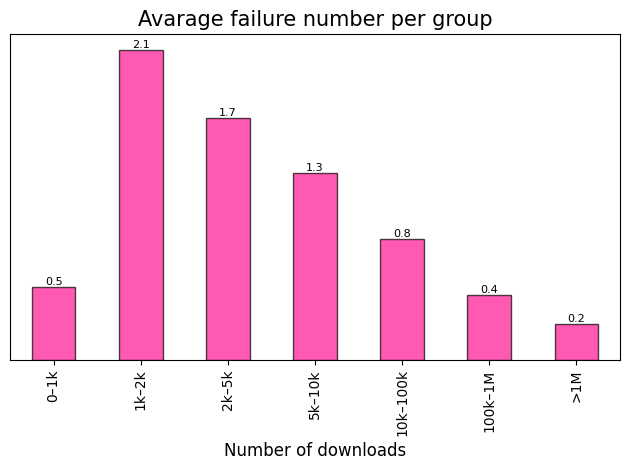

In [23]:
stats = df_trimmed.groupby("download_group", observed=False)["Failed_count"].agg(
    vuln_rate="mean"
)

ax = stats["vuln_rate"].plot(kind="bar", edgecolor='black', alpha=0.7, color=random_color)

# Annotate each bar
for i, rate in enumerate(stats["vuln_rate"]):
    ax.text(i, rate, f"{rate:.1f}", ha="center", va="bottom", fontsize=8)

ax.get_yaxis().set_visible(False)
plt.xlabel("Number of downloads", fontsize=12)
plt.title("Avarage failure number per group", fontsize=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.grid(axis='x', visible=False) # Hiding x-grid often looks cleaner for histograms
plt.tight_layout()
plt.show()

## Does a <ins>lack of recent updates</ins> increase vulnerability risks?




In [24]:
df_trimmed.head()

,name,version,downloads,created_at,direct_deps,all_deps,a:vulnerability,a:notice,a:unmaintained,a:unsound,a:yanked,time,log-downloads,log_downloads,download_group,Failed_count,Failed_bool
0,b,0.2.0,3139,2020-02-11T01:31:37.680168Z,0,0,0,0,0,0,0,2020-02-11 01:31:37.680168+00:00,8.051978,8.051978,2k–5k,0,False
1,i,0.1.0,1091,2024-12-02T20:36:14.609300Z,0,0,0,0,0,0,0,2024-12-02 20:36:14.609300+00:00,6.995766,6.995766,1k–2k,0,False
2,ah,0.0.0,2106,2021-01-01T05:17:51.161059Z,0,0,0,0,0,0,0,2021-01-01 05:17:51.161059+00:00,7.653020,7.653020,2k–5k,0,False
3,b3,0.1.9,1815,2023-10-26T17:13:29.445821Z,10,35,0,0,1,0,0,2023-10-26 17:13:29.445821+00:00,7.504392,7.504392,1k–2k,0,False
4,gh,0.1.0,2337,2019-02-13T12:06:03.700438Z,1,15,0,0,0,0,0,2019-02-13 12:06:03.700438+00:00,7.757051,7.757051,2k–5k,0,False


In [25]:
snapshot_time = df_trimmed["time"].max()
snapshot_time

Timestamp('2025-12-08 12:12:02.518797+0000', tz='UTC')

In [26]:
df_trimmed["days_since_release"] = (snapshot_time - df_trimmed["time"]).dt.days

In [27]:
df_trimmed["days_since_release"].describe()

count    186287.000000
mean        893.772367
std         827.002717
min           0.000000
25%         216.000000
50%         653.000000
75%        1351.000000
max        4045.000000
Name: days_since_release, dtype: float64

In [28]:
year = 365
bins = [0, year*1, year*3, year*6, year*10, np.inf]
labels = ["0–1y", "1–3y", "3–6y", "6–10y", ">10y"]

df_trimmed["release_age_group"] = pd.cut(
    df_trimmed["days_since_release"], bins=bins, labels=labels, include_lowest=True
)
age_stats = df_trimmed.groupby("release_age_group", observed=False)["Failed_bool"].agg(
    vuln_rate="mean", n="count"
)

age_stats["vuln_rate"] *= 100
age_stats

,vuln_rate,n
release_age_group,,
0–1y,22.130910,65465
1–3y,28.855804,60584
3–6y,38.767718,43740
6–10y,36.828579,15564
>10y,23.447537,934


### Do Less Recently Released Packages Have More Vulnerabilities?

In this analysis, we examine whether packages that have not been released recently are more likely to contain vulnerability-related issues. Since creation dates are not available, we use the publication date of the latest package version as an indicator of how recently a package has been maintained.

Release recency is measured as the number of months since the most recent release. Vulnerability is represented as a binary variable indicating whether a package has at least one vulnerability-related flag.

The analysis starts by comparing vulnerability rates across groups of packages with different release ages. This provides an intuitive view of how security risk varies with release recency. We then apply statistical tests to evaluate whether the observed pattern reflects a systematic association rather than random variation. Finally, we use a regression model to estimate the relationship between release recency and vulnerability probability while accounting for other factors such as package popularity and dependency counts.

Because release recency is an imperfect proxy for maintenance quality, the results are interpreted as correlations rather than evidence of causation.


## Hypothesis: Release Recency and Vulnerability Count

In software ecosystems, packages differ widely in how frequently they are updated. A package whose latest release occurred a long time ago may be less actively maintained, potentially increasing the likelihood that known vulnerabilities remain unresolved. In the absence of creation-time or development-activity data, the time since the **most recent release** can be used as a proxy for maintenance recency.

The goal of this analysis is to test whether packages whose latest release is older tend to exhibit **more detected vulnerabilities**.

Formally, we consider the following hypothesis:

- **Null hypothesis (H₀):**  
  The number of detected vulnerabilities is independent of the time since the last package release.

- **Alternative hypothesis (H₁):**  
  Packages with older last releases tend to have a higher number of detected vulnerabilities.

The analysis focuses on a single explanatory variable—**months since last release**—and does not incorporate additional package characteristics. Therefore, results are interpreted as associations rather than causal effects.


In [29]:
from scipy import stats

df_trimmed["Failed_count"] = df_trimmed["a:vulnerability"]+ df_trimmed["a:unsound"]
# 1. Setup Data
x = df_trimmed["days_since_release"]
y = df_trimmed["Failed_count"]

# 2. Define Tests with Definitions and Wiki Links
correlation_tests = [
    {
        "name": "Pearson",
        "func": stats.pearsonr,
        "wiki": "(https://en.wikipedia.org/wiki/Pearson_correlation_coefficient)"
    },
    {
        "name": "Spearman",
        "func": stats.spearmanr,
        "wiki": "(https://en.wikipedia.org/wiki/Spearman%27s_rank_correlation_coefficient)"
    },
    {
        "name": "Kendall",
        "func": stats.kendalltau,
        "wiki": "(https://en.wikipedia.org/wiki/Kendall_rank_correlation_coefficient)"
    }
]

# 3. Build the Markdown Table
md_table = []
md_table.append("| Test | Coefficient | P-Value | Result |")
md_table.append("| :--- | :--- | :--- | :--- |")

for test in correlation_tests:
    try:
        # Run test
        res = test["func"](x, y)
        
        # Handle different return types
        coef = res.statistic if hasattr(res, 'statistic') else res[0]
        p_val = res.pvalue if hasattr(res, 'pvalue') else res[1]
        
        # Formatting
        significance_icon = "🟢" if p_val < 0.05 else "🔴"
        significance_text = "**Significant**" if p_val < 0.05 else "Not Sig"
        
        row = (
            f"| [**{test['name']}**]{test['wiki']} | "
            f"`{coef:.4f}` | "
            f"`{p_val:.4f}` | "
            f"{significance_icon} {significance_text} | "
        )
        md_table.append(row)
        
    except Exception as e:
        md_table.append(f"| **{test['name']}** | Error | — | {str(e)} | {test['definition']} | {test['wiki']} |")

final_markdown = "\n".join(md_table)

# 4. Display
print("--- Copy Markdown Below ---")
print(final_markdown)

--- Copy Markdown Below ---
| Test | Coefficient | P-Value | Result |
| :--- | :--- | :--- | :--- |
| [**Pearson**](https://en.wikipedia.org/wiki/Pearson_correlation_coefficient) | `0.1866` | `0.0000` | 🟢 **Significant** | 
| [**Spearman**](https://en.wikipedia.org/wiki/Spearman%27s_rank_correlation_coefficient) | `0.1839` | `0.0000` | 🟢 **Significant** | 
| [**Kendall**](https://en.wikipedia.org/wiki/Kendall_rank_correlation_coefficient) | `0.1423` | `0.0000` | 🟢 **Significant** | 


## Hypothesis: Dependency Count and Vulnerability Exposure

Packages vary widely in the number of dependencies they rely on. A larger dependency graph increases code complexity and introduces transitive exposure to external components, which may increase the likelihood of security issues.

In this analysis, we test whether the total number of dependencies of a package is associated with the number of detected vulnerabilities.

The hypotheses are defined as follows:

- **Null hypothesis (H₀):**  
  The number of detected vulnerabilities is independent of the total number of dependencies of a package.

- **Alternative hypothesis (H₁):**  
  Packages with a higher total number of dependencies tend to exhibit a higher number of detected vulnerabilities.

The analysis focuses on a single explanatory variable (`all_deps`) and treats the results as associations rather than causal effects.


In [30]:
from scipy import stats

df_trimmed["Failed_count"] = df_trimmed["a:vulnerability"]+ df_trimmed["a:unsound"]
# 1. Setup Data
x = df_trimmed["all_deps"]
y = df_trimmed["Failed_count"]

# 2. Define Tests with Definitions and Wiki Links
correlation_tests = [
    {
        "name": "Pearson",
        "func": stats.pearsonr,
        "wiki": "(https://en.wikipedia.org/wiki/Pearson_correlation_coefficient)"
    },
    {
        "name": "Spearman",
        "func": stats.spearmanr,
        "wiki": "(https://en.wikipedia.org/wiki/Spearman%27s_rank_correlation_coefficient)"
    },
    {
        "name": "Kendall",
        "func": stats.kendalltau,
        "wiki": "(https://en.wikipedia.org/wiki/Kendall_rank_correlation_coefficient)"
    }
]

# 3. Build the Markdown Table
md_table = []
md_table.append("| Test | Coefficient | P-Value | Result |")
md_table.append("| :--- | :--- | :--- | :--- |")

for test in correlation_tests:
    try:
        # Run test
        res = test["func"](x, y)
        
        # Handle different return types
        coef = res.statistic if hasattr(res, 'statistic') else res[0]
        p_val = res.pvalue if hasattr(res, 'pvalue') else res[1]
        
        # Formatting
        significance_icon = "🟢" if p_val < 0.05 else "🔴"
        significance_text = "**Significant**" if p_val < 0.05 else "Not Sig"
        
        row = (
            f"| [**{test['name']}**]{test['wiki']} | "
            f"`{coef:.4f}` | "
            f"`{p_val:.4f}` | "
            f"{significance_icon} {significance_text} | "
        )
        md_table.append(row)
        
    except Exception as e:
        md_table.append(f"| **{test['name']}** | Error | — | {str(e)} | {test['definition']} | {test['wiki']} |")

final_markdown = "\n".join(md_table)

# 4. Display
print("--- Copy Markdown Below ---")
print(final_markdown)

--- Copy Markdown Below ---
| Test | Coefficient | P-Value | Result |
| :--- | :--- | :--- | :--- |
| [**Pearson**](https://en.wikipedia.org/wiki/Pearson_correlation_coefficient) | `0.3472` | `0.0000` | 🟢 **Significant** | 
| [**Spearman**](https://en.wikipedia.org/wiki/Spearman%27s_rank_correlation_coefficient) | `0.5611` | `0.0000` | 🟢 **Significant** | 
| [**Kendall**](https://en.wikipedia.org/wiki/Kendall_rank_correlation_coefficient) | `0.4486` | `0.0000` | 🟢 **Significant** | 
